# 데이터 셋 확인

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Matplotlib의 시각화를 간편하고 세련되게 만든다.
import keras
import sklearn

In [2]:
plt.style.use('seaborn-v0_8') # Matplotlib 디자인에서 seaborn 스타일로 디자인(테마) 변경
sns.set(font_scale=2.5) # 글자 크기를 2.5배 키우기 위해 작성
import missingno as msno # 데이터의 빈칸을 확인하기 위해 시각화 라이브러리

In [3]:
import warnings
warnings.filterwarnings('ignore') # 워닝 메세지 생략하는 기능
%matplotlib inline

In [4]:
os.listdir(".")

['.ipynb_checkpoints',
 '1. Kaggle Guide.ipynb',
 'gender_submission.csv',
 'test.csv',
 'train.csv',
 'Untitled.ipynb']

In [5]:
df_train= pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_submit = pd.read_csv('gender_submission.csv')

In [6]:
df_train.shape, df_test.shape, df_submit.shape

((891, 12), (418, 11), (418, 2))

In [7]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df_submit.columns

Index(['PassengerId', 'Survived'], dtype='object')

In [23]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df_submit.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [11]:
df_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [12]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
df_train.isnull().sum() / df_train.shape[0]

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

# [통계 검정] 성별에 따른 평균 요금에는 차이가 있을까?

In [22]:
from scipy import stats
male_fare = df_train[df_train['Sex'] =='male']['Fare'].dropna()
female_fare = df_train[df_train['Sex'] == 'female']['Fare'].dropna()

print(f"남성 데이터 개수 : {len(male_fare)}, 여성 데이터 개수 : {len(female_fare)}")

levene_stat, levene_p = stats.levene(male_fare, female_fare) # 등분산성 검정 (Levene 검정), p-value가 0.05보다 작으면 '분산이 다르다'고 판단
print(f"Levene Test p-value: {levene_p:.4f}")

# T-test 수행 (등분산성 검정 결과에 따라 분기)
if np.isnan(levene_p):
    print("오류: 데이터에 문제가 있어 등분산성 검정을 수행할 수 없습니다.")
else:
    if levene_p > 0.05: # 분산이 같을 때 
        t_test, p_val = stats.ttest_ind(male_fare, female_fare, equal_var=True)
        print("결과: 등분산성 만족, Student's T-test 진행")
    else: # 분산이 다를 때
        t_test, p_val = stats.ttest_ind(male_fare, female_fare, equal_var=False)
        print("결과: 등분산성 불충족, Welch's T-test 진행")

print(f"최종 T-test p-value :{p_val:.8f}")

남성 데이터 개수 : 577, 여성 데이터 개수 : 314
Levene Test p-value: 0.0000
결과: 등분산성 불충족, Welch's T-test 진행
최종 T-test p-value :0.00000054


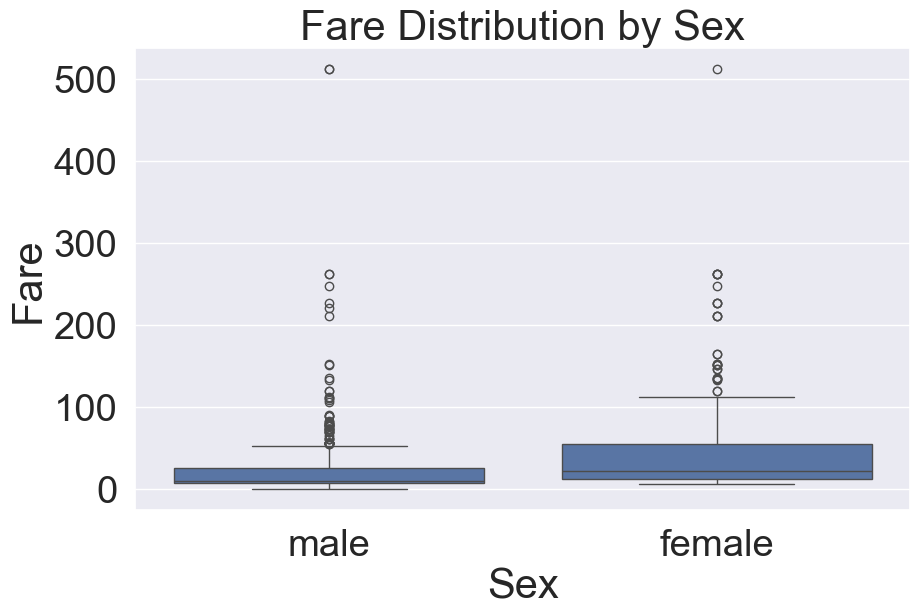

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sex', y='Fare', data=df_train)
plt.title('Fare Distribution by Sex')
plt.show()

## 성별(Sex=male, female)에 따른 요금(Fare) 차이 분석
**[분석 방법]** : 독립표본 T-검정 (independent T-tset)<br>
**[조건 확인]**<br>
- 정규성(Normality): 데이터가 정규분포를 따르지는 않지만, 샘플 수가 충분하므로 중심극한정리(CLT)에 의해T-검정을 수행함.<br>
- 등분산성(Homogeneity if Variance): 등분산성 검정 결과 등분산성 불충족으로, Welch's T-test 진행함.<br>
- 독립성(Independence): 본 분석은 승객의 데이터가 독립적으로 수집되었다고 가정하며, 중복 측정 데이터가 아니므로 독립표본 T-검정의 독립성 가정을 충족하는 것으로 판단함.<br>
**[가설 검정]**<br>
- 귀무가설(H0): 남성과 여성의 평균 요금은 차이가 없다.<br>
- 대립가설(H1): 남성과 여성의 평균 요금은 통계적으로 유의미한 차이가 있다.<br>
**[분석 결과]** : p-value가 `0.00000054`로 유의수준 0.05보다 매우 작게 나타남.<br>
**[결론]** : 귀무가설을 기각하고 대립가설을 채택함. 즉, 성별에 따른 요금 차이는 통계적으로 매우 유의미하며, 여성이 남성에 비해 상대적으로 높은 요금을 지불했음을 알 수 있음. 

## 등분산성 시각적 확인
**[분석 결과]** <br>
- Botplot을 통해 확인한 결과, 여성(female) 집단의 요금 분포가 남성(male) 집단에비해 훨씬 넓게 퍼져 있음을 알 수 있다. 이러한 시각적 증거는 앞서 수행한 Levene의 등분산성 검정 결과(p < 0.05)와 일치한다.

# [통계 검정] 객실 등급(Pclass)에 따라 생존율이 진짜 다른가?

In [54]:
pclass_survived_ct = pd.crosstab(df_train['Pclass'], df_train['Survived'], margins=True)
pclass_survived_ct

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


In [53]:
# chi2:카이제곱통계량, p_val:유의확률, dof:자유도, expected:기대빈도
chi2, p_val, dof, expected = stats.chi2_contingency(pclass_survived_ct)

print(f"카이제곱 통계량: {chi2:.4f}")
print(f"p-value: {p_val:.10f}")

if p_val < 0.05:
    print("\n 결론: p-value가 0.05보다 작으므로, 객실 등급(Pclass)과 생존 여부(Survived) 사이에는 통계적으로 유의미한 관계가 있습니다.")
else:
    print("\n결론: p-value가 0.05보다 크므로, 객실 등급과 생존 여부는 서로 독립적입니다.")

카이제곱 통계량: 102.8890
p-value: 0.0000000000

 결론: p-value가 0.05보다 작으므로, 객실 등급(Pclass)과 생존 여부(Survived) 사이에는 통계적으로 유의미한 관계가 있습니다.


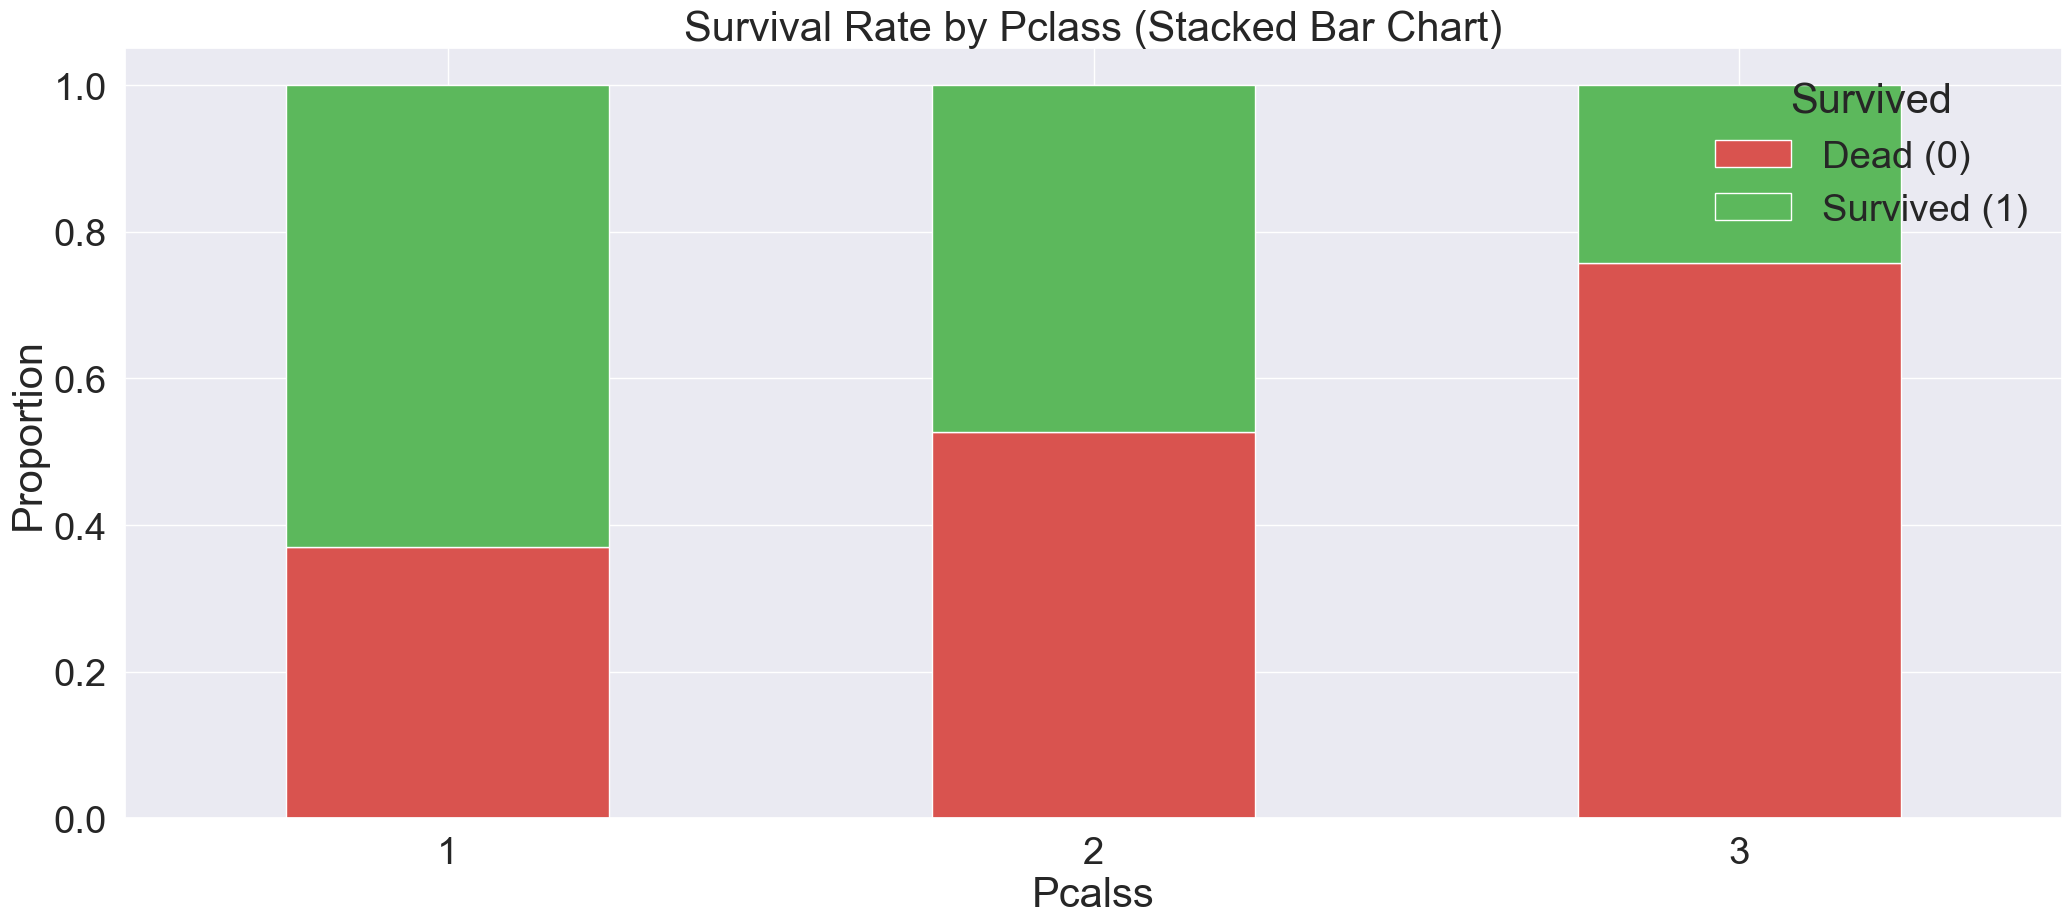

In [50]:
pclass_survived_pct = pclass_survived_ct.div(pclass_survived_ct.sum(1), axis=0)

pclass_survived_pct.plot(kind='bar', stacked=True, figsize=(25,10), color=['#d9534f', '#5cb85c'])
plt.title('Survival Rate by Pclass (Stacked Bar Chart)')
plt.xlabel('Pcalss')
plt.ylabel('Proportion')
plt.legend(title='Survived', labels=['Dead (0)', 'Survived (1)'], loc = 'best')
plt.xticks(rotation=0)
plt.show()

## 객실 등급(Pclass)과 생존 여부(Survived)의 상관성 분석
**[분석 방법]** 카이제곱 독립성 검정 (Chi-square Test of Independence) <br>
**[가설 검정]**<br>
- 귀무가설(H0): 객실 등급과 생존 여부는 서로 독립이다(관련이 없다).<br>
- 대립가설(H1): 객실 등급과 생존 여부는 서로 독립이 아니다(관련이 있다).<br>
**[분석 결과]**: p-value가 `0.0000000000` 미만으로 나타나 유의수준 0.05에서 귀무가설을 기각함.<br>
**[결론]**: 객실 등급이 높을수록(1등급) 생존율이 유의미하게 높게 나타나며, 이는 사회경제적 지위가 생존에 영향을 주었음을 통계적으로 증명함.

# [통계 검정] 객실 등급(1,2,3등석)별로 승객의 평균 나이(Age)가 다른가? 

In [62]:
age_p1 = df_train[df_train['Pclass'] == 1]['Age'].dropna()
age_p2 = df_train[df_train['Pclass'] == 2]['Age'].dropna()
age_p3 = df_train[df_train['Pclass'] == 3]['Age'].dropna()

print(f"등석 인원: {len(age_p1)}, 2등석 인원:{len(age_p2)}, 3등석 인원:{len(age_p3)}")

# 등분산성 검정
levene_stat, levene_p = stats.levene(age_p1, age_p2, age_p3)
print(f"Levene Test p-value : {levene_p:.4f}")

print("--- 등분산성 만족했을 때 ---")
# 일원 분산 분석(One-way ANOVA) 수행
f_stat, p_val = stats.f_oneway(age_p1, age_p2, age_p3)
print(f"ANOVA F-통계량 : {f_stat:.4f}")
print(f"ANOVA p-value : {p_val:.10f}")

if p_val < 0.05:
    print("\n결론 : p-value가 0.05보다 작으므로, 객실 등급별 승객의 평균 나이는 통계적으로 유의미한 차이가 있습니다.")
else:
    print("\n결론 : p-value가 0.05보다 크므로, 객실 등급별 평균 나이 차이는 통계적으로 유의미하지 않습니다.")

print(" --- 등분산성 불충족 했을 때 --- ")
k_stat, p_val_k = stats.kruskal(age_p1, age_p2, age_p3)
print(f"Kruskal-Wallis 통계량 : {k_stat:.4f}")
print(f"Kruskal-Wallis p-value: {p_val_k:.10f}")

if p_val_k < 0.05:
    print("\n결론: 등분산성이 만족되지 않아 비모수 검정인 Kruskal-Wallis를 수행함.")
    print("분석 결과 p-value가 0.05보다 작으므로, 여전히 객실 등급별 나이 차이는 유의미한 것으로 나타남.")

등석 인원: 186, 2등석 인원:173, 3등석 인원:355
Levene Test p-value : 0.0038
--- 등분산성 만족했을 때 ---
ANOVA F-통계량 : 57.4435
ANOVA p-value : 0.0000000000

결론 : p-value가 0.05보다 작으므로, 객실 등급별 승객의 평균 나이는 통계적으로 유의미한 차이가 있습니다.
 --- 등분산성 불충족 했을 때 --- 
Kruskal-Wallis 통계량 : 95.9948
Kruskal-Wallis p-value: 0.0000000000

결론: 등분산성이 만족되지 않아 비모수 검정인 Kruskal-Wallis를 수행함.
분석 결과 p-value가 0.05보다 작으므로, 여전히 객실 등급별 나이 차이는 유의미한 것으로 나타남.


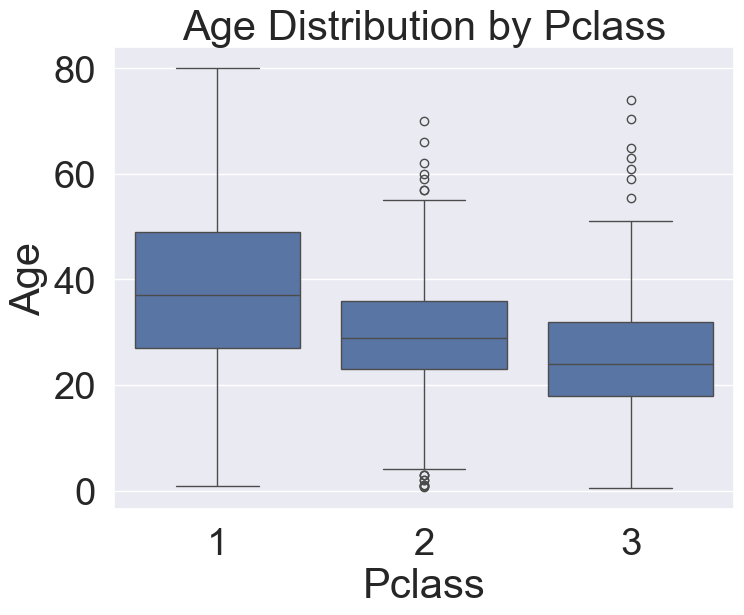

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y='Age', data=df_train)
plt.title('Age Distribution by Pclass')
plt.show()

## 객실 등급(Pclass)에 따른 평균 나이(Age) 차이 분석
**[분석 방법]** : 일원 분산 분석 (One-way ANOVA) <br>
**[가설 설정]** <br>
- 귀무가설(H0): 모든 객실 등급의 평균 나이는 동일하다.<br>
- 대립가설(H1): 적어도 하나의 객실 등급은 평균 나이가 다르다. <br>
**[분석 결과]** : p-value가 `0.0000000000` 으로 나타나 유의수준 0.05에서 귀무가설을 기각함.<br>
**[결론]** : 객실 등급간 연령대의 차이가 뚜렷하며, 이는 등급별 승객의 인구통계학적 특성이 다름을 시사함.(1등석일수록 고연령층 분포가 높음) 

1. **가정 확인**: Levene의 등분산성 검정 결과 p-value(0.0038)가 0.05보다 작아 **등분산 가정이 위배됨**을 확인하였다.
2. **분석 방법 수정**: 일반적인 일원 분산 분석(One-way ANOVA)을 그대로 신뢰하기 어려우므로, 분산의 차이에 영향을 받지 않는 **비모수 검정법인 Kruskal-Wallis Test를 추가로 수행**하였다.
3. **최종 결론**: Kruskal-Wallis 검정 결과 역시 p-value가 매우 작게(0.0000...) 나타났으므로, 객실 등급별 승객의 연령대 차이는 통계적으로 매우 확고한 사실임을 입증하였다.